### Imports

In [11]:
# Imports
import sys
import pandas as pd
import os
import glob
import numpy as np
sys.path.append(os.path.abspath("algorithm"))
from pathlib import Path
import sys

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score,classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from src.hcm_transcription.mapping import MAPPING
from src.hcm_transcription.utils import ORNAMENT_MAPPING,extract_ornament_segments, df_to_anno, normalize_target_label, TARGET_LABELS, TARGET_LABEL_GROUPS, TARGET_LABEL_ALIASES, TARGET_LABEL_PRIORITY

### Load dataset
Ornamentation segments where extracted from the annotated dataset and their pitch curves were loaded.

In [12]:
def get_cross_platform_path(base_dir, file_name):
    """Finds the correct file regardless of how Mac or Windows handled the ':' character."""
    exact_path = os.path.join(base_dir, file_name)
    if os.path.exists(exact_path):
        return exact_path
    
    # Try all the common ways Windows/Mac unzippers replace colons
    variants =[
        file_name.replace(' : ', ' _ '),  # Mac / CompIAM replacement
        file_name.replace(':', '_'),      # Standard Windows replacement
        file_name.replace(':', '-'),      # 7-Zip replacement
        file_name.replace(':', '')        # Stripped entirely
    ]
    
    for variant in variants:
        test_path = os.path.join(base_dir, variant)
        if os.path.exists(test_path):
            return test_path
            
    # As a last resort, use a wildcard to find anything matching the name
    pattern = os.path.join(base_dir, file_name.replace(':', '*'))
    matches = glob.glob(pattern)
    if matches:
        return matches[0]
        
    return exact_path # Let it return the original so the warning triggers properly


def extract_ornament_segments(raga_names, data_home, annotation_base="Ornamentation-In-Hindustani-Vocals-Dataset"):
    segments =[]
    skipped_labels = set()
    
    for raga_name in raga_names:
        if raga_name not in MAPPING:
            print(f"Skipping {raga_name} - not in MAPPING")
            continue
            
        data = MAPPING[raga_name]
        
        # --- Cross-Platform Path Resolution ---
        raw_anno_name = list(data['annotators'].values())[0]
        annotation_file = get_cross_platform_path(annotation_base, raw_anno_name)
        
        saraga_dir = f"{data_home}/saraga1.5_hindustani"
        raw_pitch_name = f"{data['audio_path']}.pitch.txt"
        pitch_path = get_cross_platform_path(saraga_dir, raw_pitch_name)

        print(f"Loading {raga_name}...")
        
        if not os.path.exists(pitch_path):
            print(f"  WARNING: pitch file not found, skipping. Looked for: {pitch_path}")
            continue
        if not os.path.exists(annotation_file):
            print(f"  WARNING: annotation file not found, skipping. Looked for: {annotation_file}")
            continue
            
        # Load pitch data
        df_pitch = pd.read_csv(pitch_path, sep="\t", header=None)
        df_pitch.columns = ["time", "f0"]
        df_pitch["log_f0"] = df_pitch["f0"].apply(lambda x: np.log2(x) if x > 0 else np.nan)
        
        # Load annotations
        df_raw = pd.read_csv(annotation_file, header=None)
        anno = df_to_anno(df_raw)
        
        # Track skipped labels
        skipped_labels.update(
            label for label in anno["label"].dropna().unique()
            if normalize_target_label(label) is None
        )
        
        # Remap all labels using normalize_target_label
        anno = anno.assign(label=anno["label"].map(normalize_target_label))
        
        # Filter to target labels only
        anno_filtered = anno[anno['label'].isin(TARGET_LABELS)].reset_index(drop=True)
        print(f"  Found {len(anno_filtered)} target ornaments out of {len(anno)} total")
        
        for _, row in anno_filtered.iterrows():
            mask = (df_pitch["time"] >= row['time_s']) & (df_pitch["time"] <= row['time_e'])
            segment_pitch = df_pitch[mask]["log_f0"].values
            
            if len(segment_pitch) == 0 or np.isnan(segment_pitch).mean() > 0.3:
                continue
                
            segment_pitch = pd.Series(segment_pitch).interpolate().fillna(0).values
            segments.append({
                "raga": raga_name,
                "label": row['label'],
                "time_s": row['time_s'],
                "time_e": row['time_e'],
                "duration": row['duration'],
                "pitch_curve": segment_pitch
            })

    # Summary
    df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} 
                                  for s in segments])
    print(f"\n=== Extraction Summary ===")
    print(f"Total segments: {len(segments)}")
    
    if not df_segments.empty:
        print(f"Label distribution:\n{df_segments['label'].value_counts()}")
        print(f"Duration stats:\n{df_segments['duration'].describe()}")
    
    print(f"Skipped ornament types: {sorted(skipped_labels)}")
    return segments

In [3]:
raga_names = MAPPING.keys()
data_home = r"C:\Users\despn\Downloads\MIR"
annotation_base = r"C:\Users\despn\Downloads\MIR\hindustani-ornamentation-classification\Ornamentation-In-Hindustani-Vocals-Dataset"

segments = extract_ornament_segments(raga_names, data_home, annotation_base)

Loading Aahir Bhairon...
  Found 149 target ornaments out of 149 total
Loading Bairagi...
  Found 89 target ornaments out of 89 total
Loading Bhairavi Dadra...
  Found 96 target ornaments out of 96 total
Loading Irani Bhairavi...
  Found 103 target ornaments out of 103 total
Loading Kalavati...
  Found 137 target ornaments out of 137 total
Loading Malkauns...
  Found 97 target ornaments out of 97 total
Loading Chandrakauns...
  Found 91 target ornaments out of 91 total
Loading Majh Khamaj Thumri...
  Found 121 target ornaments out of 121 total
Loading Nat Bhairon...
  Found 212 target ornaments out of 212 total
Loading Raageshree...
  Found 157 target ornaments out of 157 total
Loading Todi...
  Found 202 target ornaments out of 204 total

=== Extraction Summary ===
Total segments: 1381
Label distribution:
label
Kan        480
Murki      434
Meend      430
Andolan     37
Name: count, dtype: int64
Duration stats:
count    1381.000000
mean        0.834393
std         0.716238
min        

### Data inspection

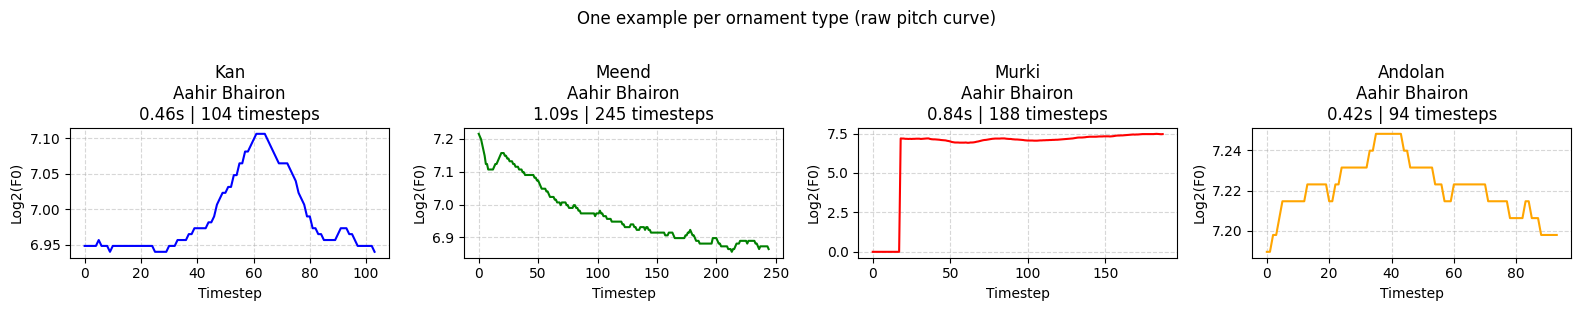

In [25]:
import matplotlib.pyplot as plt
# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = {"Kan": "blue", "Meend": "green", "Murki": "red", "Andolan": "orange"}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):
    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)
    
    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue
    
    curve = example['pitch_curve']
    ax.plot(curve, color=colors[label], linewidth=1.5)
    ax.set_title(f"{label}\n{example['raga']}\n{example['duration']:.2f}s | {len(curve)} timesteps")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))

print("\n=== Duration Stats per Raga ===")
print(df_segments.groupby('raga')['duration'].describe().round(3))

=== Class Distribution ===
label
Kan        480
Murki      434
Meend      430
Andolan     37
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
         count   mean    std    min    25%    50%    75%    max
label                                                          
Andolan   37.0  0.976  1.019  0.107  0.276  0.575  1.443  4.644
Kan      480.0  0.434  0.371  0.055  0.222  0.320  0.522  2.771
Meend    430.0  0.869  0.611  0.174  0.518  0.706  1.020  4.889
Murki    434.0  1.231  0.829  0.017  0.653  0.990  1.567  5.203

=== Timestep Stats per Class ===
         count   mean    std   min    25%    50%    75%     max
label                                                          
Andolan   37.0  219.6  229.4  24.0   61.0  129.0  325.0  1045.0
Kan      480.0   97.6   83.4  12.0   50.0   72.0  118.0   623.0
Meend    430.0  195.5  137.5  39.0  117.0  159.0  229.8  1101.0
Murki    434.0  277.1  186.6   4.0  147.0  223.0  353.0  1171.0

=== Duration Stats per Raga ===
  

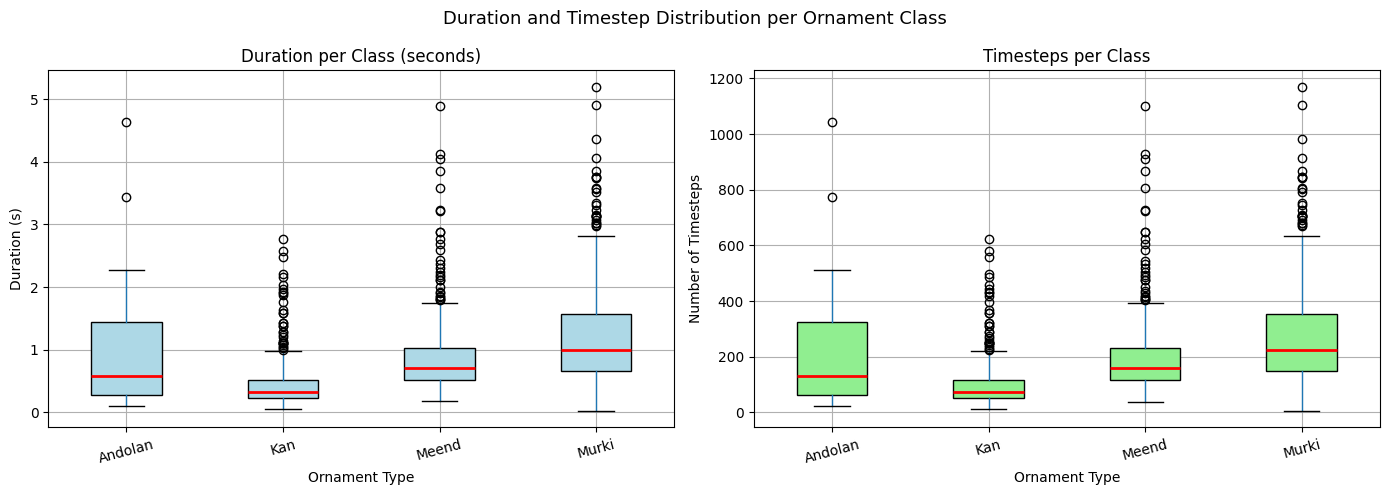

In [4]:
# Build dataframe from segments
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration boxplot
df_segments.boxplot(column='duration', by='label', ax=axes[0], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Duration per Class (seconds)")
axes[0].set_xlabel("Ornament Type")
axes[0].set_ylabel("Duration (s)")
plt.sca(axes[0])
plt.xticks(rotation=15)

# Timesteps boxplot
df_segments.boxplot(column='num_timesteps', by='label', ax=axes[1],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Timesteps per Class")
axes[1].set_xlabel("Ornament Type")
axes[1].set_ylabel("Number of Timesteps")
plt.sca(axes[1])
plt.xticks(rotation=15)

plt.suptitle("")  # remove auto title from boxplot
fig.suptitle("Duration and Timestep Distribution per Ornament Class", fontsize=13)
plt.tight_layout()
plt.show()

### Data augmentation
Due to the limited amount of data we do time-stretching augmentation

In [13]:
def augment_pitch_curve(curve, noise_std=0.01, stretch_range=(0.8, 1.2)):
    """
    Applies random augmentations to a pitch curve:
    - Gaussian noise
    - Time stretching (resampling)
    """
    from scipy.signal import resample
    
    # Random time stretch
    stretch_factor = np.random.uniform(*stretch_range)
    new_length = int(len(curve) * stretch_factor)
    curve = resample(curve, new_length)
    
    # Add small Gaussian noise
    #curve = curve + np.random.normal(0, noise_std, len(curve))
    
    return curve


def augment_segments(segments, num_augmentations=2):
    """
    Augments each segment num_augmentations times and adds to dataset.
    """
    augmented = []
    for seg in segments:
        augmented.append(seg)  # keep original
        
        for _ in range(num_augmentations):
            aug_curve = augment_pitch_curve(seg['pitch_curve'].copy())
            augmented.append({
                "raga": seg['raga'],
                "label": seg['label'],
                "time_s": seg['time_s'],
                "time_e": seg['time_e'],
                "duration": seg['duration'],
                "pitch_curve": aug_curve
            })
    
    print(f"Original: {len(segments)} → Augmented: {len(augmented)} segments")
    return augmented

segments_aug = augment_segments(segments, num_augmentations=2)

Original: 1381 → Augmented: 4143 segments


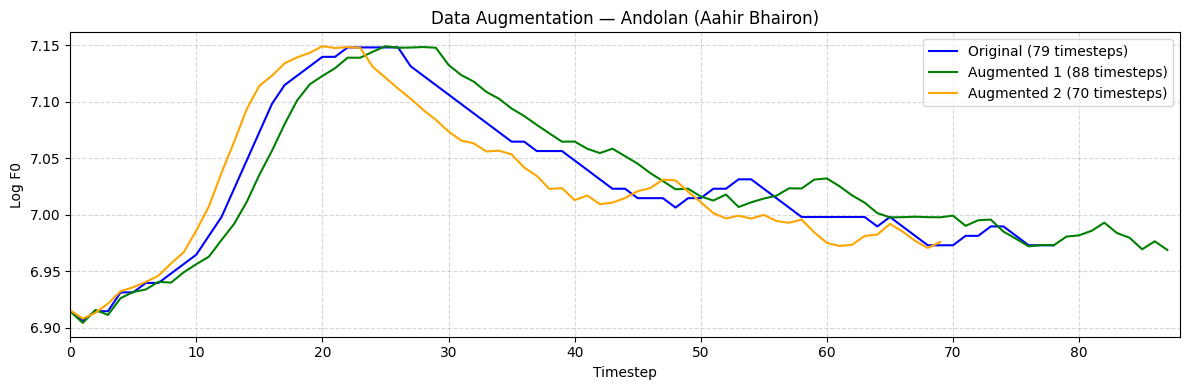

In [14]:
# Pick one example per augmentation to visualize
fig, ax = plt.subplots(figsize=(12, 4))

original = segments[10]
aug1 = augment_pitch_curve(original['pitch_curve'].copy())
aug2 = augment_pitch_curve(original['pitch_curve'].copy())

ax.plot(original['pitch_curve'], color='blue', linewidth=1.5, label=f"Original ({len(original['pitch_curve'])} timesteps)")
ax.plot(aug1, color='green', linewidth=1.5, label=f"Augmented 1 ({len(aug1)} timesteps)")
ax.plot(aug2, color='orange', linewidth=1.5, label=f"Augmented 2 ({len(aug2)} timesteps)")

ax.set_xlim(0, max(len(original['pitch_curve']), len(aug1), len(aug2)))
ax.set_xlabel("Timestep")
ax.set_ylabel("Log F0")
ax.set_title(f"Data Augmentation — {original['label']} ({original['raga']})")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Preprocess

Each ornament's log-F0 curve is normalized, padded or truncated to a fixed length of 200 timesteps, and split into stratified 80/20 train/test `DataLoader`s for batched training. The length size was chosen based on the statistical analysis, where the 75th percentile of the dataset's timestep distribution is around 230 timesteps.

All of them are very versatile
* Kan is short — median 72, 75th percentile 118
* Murki is long — median 229, 75th percentile 353
* Meend is medium — median 223, 75th percentile 230
* Andolan is very variable — median 159, 75th percentile 129 but max 1045

In [15]:
def prepare_tcn_input(segments, fixed_length=200):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

### Model

The TCN consists of six stacked residual blocks with exponentially increasing dilations (1, 2, 4, 8, 16, 32), each containing two dilated 1D convolutions with batch normalization, dropout, and a residual connection. The output is collapsed via global average pooling and passed to a linear classifier producing scores over the four ornament classes.

In [31]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
            ResidualBlock(channels, kernel_size, dilation=16),  # new
            ResidualBlock(channels, kernel_size, dilation=32),  #new
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # collapses any length to 1
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

The model is trained with Adam and class-weighted cross-entropy loss to handle class imbalance, saving both the latest and best-performing checkpoints after each epoch.

In [17]:
def train_tcn(train_loader, test_loader, model, checkpoint_name="tcn", num_classes=4, epochs=30, checkpoint_dir="checkpoints"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle both TensorDataset and custom Dataset
    try:
        all_labels = train_loader.dataset.tensors[1].numpy()
    except AttributeError:
        all_labels = train_loader.dataset.y.numpy()
        
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    best_test_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for batch in train_loader:
            xb, yb = batch[0], batch[1]  # works for (xb,yb) and (xb,yb,lengths)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)

        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                xb, yb = batch[0], batch[1]
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
                
        test_acc = test_correct / test_total
        print(f"Epoch {epoch+1:02d} | Loss: {train_loss/len(train_loader):.4f} | Train Acc: {correct/total:.3f} | Test Acc: {test_acc:.3f}")
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_acc': test_acc,
        }
        torch.save(checkpoint, os.path.join(checkpoint_dir, f"{checkpoint_name}_latest.pth"))
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(checkpoint, os.path.join(checkpoint_dir, f"{checkpoint_name}_best.pth"))
            print(f"  -> New best Test Acc: {best_test_acc:.3f}")
    
    return model


### Functions for error visualization


In [22]:
def visualize_class_errors(model, test_loader, label_map, true_class, pred_class, max_plots=3):
    """
    Plots misclassified ornaments (true_class predicted as pred_class)
    alongside correct predictions of the same class for comparison.
    """
    idx_to_label = {v: k for k, v in label_map.items()}
    true_idx = label_map[true_class]
    pred_idx = label_map[pred_class]
    
    model.eval()
    all_preds, all_labels, all_inputs = [], [], []
    
    with torch.no_grad():
        for batch in test_loader:
            xb, yb = batch[0], batch[1]
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
            all_inputs.extend(xb.squeeze(1).numpy())
    
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_inputs = np.array(all_inputs)
    
    # Find correct and misclassified indices
    error_idx   = np.where((all_labels == true_idx) & (all_preds == pred_idx))[0]
    correct_idx = np.where((all_labels == true_idx) & (all_preds == true_idx))[0]
    
    print(f"Correct {true_class}: {len(correct_idx)}")
    print(f"{true_class} misclassified as {pred_class}: {len(error_idx)}")
    
    if len(error_idx) == 0:
        print("No such misclassifications found!")
        return
    
    num_to_plot = min(max_plots, len(error_idx), len(correct_idx))
    
    # 2 columns: left=correct, right=misclassified
    fig, axes = plt.subplots(num_to_plot, 2, figsize=(12, num_to_plot * 3))
    if num_to_plot == 1:
        axes = axes[np.newaxis, :]  # ensure 2D indexing works
    
    for i in range(num_to_plot):
        # Left — correct prediction
        ax_correct = axes[i][0]
        curve_correct = all_inputs[correct_idx[i]]
        ax_correct.plot(curve_correct, color='green', linewidth=1.5)
        nonzero = np.where(curve_correct != 0)[0]
        if len(nonzero) > 0:
            ax_correct.axvspan(nonzero[-1], len(curve_correct), 
                               color='gray', alpha=0.2, label='padding')
        ax_correct.set_title(f"True: {true_class} — Predicted: {true_class} ✓", 
                             color='green', fontsize=10)
        ax_correct.set_xlabel("Timestep")
        ax_correct.set_ylabel("Norm. Log F0")
        ax_correct.grid(True, linestyle='--', alpha=0.4)
        
        # Right — misclassified
        ax_error = axes[i][1]
        curve_error = all_inputs[error_idx[i]]
        ax_error.plot(curve_error, color='red', linewidth=1.5)
        nonzero = np.where(curve_error != 0)[0]
        if len(nonzero) > 0:
            ax_error.axvspan(nonzero[-1], len(curve_error), 
                             color='gray', alpha=0.2, label='padding')
        ax_error.set_title(f"True: {true_class} — Predicted: {pred_class} ✗", 
                           color='red', fontsize=10)
        ax_error.set_xlabel("Timestep")
        ax_error.set_ylabel("Norm. Log F0")
        ax_error.grid(True, linestyle='--', alpha=0.4)
    
    plt.suptitle(f"{true_class} — Correct vs Misclassified as {pred_class}", 
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### Initial trial without data augmentation for comparison

In [32]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, model=OrnamentTCN(input_size=1, num_classes=4), checkpoint_name="tcn_baseline")

X shape: (1376, 1, 200)
y shape: (1376,)
Skipped: 0
Label distribution: {'Kan': 476, 'Meend': 430, 'Murki': 433, 'Andolan': 37}
Train: 1100 | Test: 276
Epoch 01 | Loss: 1.3315 | Train Acc: 0.505 | Test Acc: 0.551
  -> New best Test Acc: 0.551
Epoch 02 | Loss: 1.2170 | Train Acc: 0.564 | Test Acc: 0.674
  -> New best Test Acc: 0.674
Epoch 03 | Loss: 1.1650 | Train Acc: 0.621 | Test Acc: 0.670
Epoch 04 | Loss: 1.1205 | Train Acc: 0.612 | Test Acc: 0.678
  -> New best Test Acc: 0.678
Epoch 05 | Loss: 1.0835 | Train Acc: 0.631 | Test Acc: 0.652
Epoch 06 | Loss: 1.0536 | Train Acc: 0.620 | Test Acc: 0.667
Epoch 07 | Loss: 1.0263 | Train Acc: 0.650 | Test Acc: 0.667
Epoch 08 | Loss: 0.9994 | Train Acc: 0.653 | Test Acc: 0.710
  -> New best Test Acc: 0.710
Epoch 09 | Loss: 0.9877 | Train Acc: 0.654 | Test Acc: 0.630
Epoch 10 | Loss: 0.9725 | Train Acc: 0.659 | Test Acc: 0.652
Epoch 11 | Loss: 0.9598 | Train Acc: 0.665 | Test Acc: 0.681
Epoch 12 | Loss: 0.9558 | Train Acc: 0.657 | Test Acc: 0.

### Evaluation

In [33]:
def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.74      0.62      0.68        96
       Meend       0.69      0.84      0.76        86
       Murki       0.91      0.49      0.64        87
     Andolan       0.11      0.71      0.20         7

    accuracy                           0.65       276
   macro avg       0.62      0.67      0.57       276
weighted avg       0.76      0.65      0.68       276

=== Per-class Metrics ===
Kan        | Precision: 0.741 | Recall: 0.625 | F1: 0.678
Meend      | Precision: 0.692 | Recall: 0.837 | F1: 0.758
Murki      | Precision: 0.915 | Recall: 0.494 | F1: 0.642
Andolan    | Precision: 0.114 | Recall: 0.714 | F1: 0.196

Macro avg  | Precision: 0.615 | Recall: 0.668 | F1: 0.568


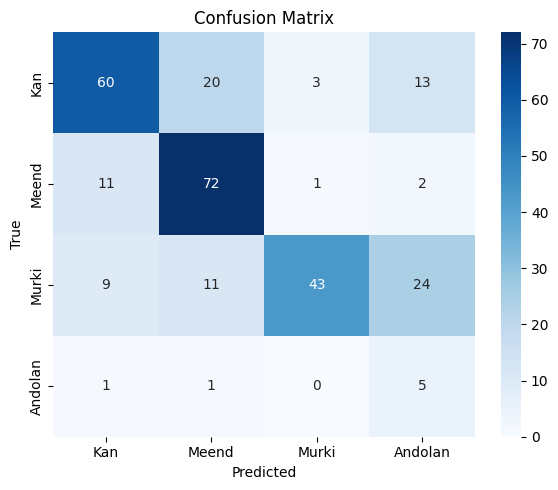

Precision: [0.74074074 0.69230769 0.91489362 0.11363636]
Recall:    [0.625      0.8372093  0.49425287 0.71428571]
F1:        [0.6779661  0.75789474 0.64179104 0.19607843]


In [34]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

Correct Meend: 57
Meend misclassified as Kan: 27


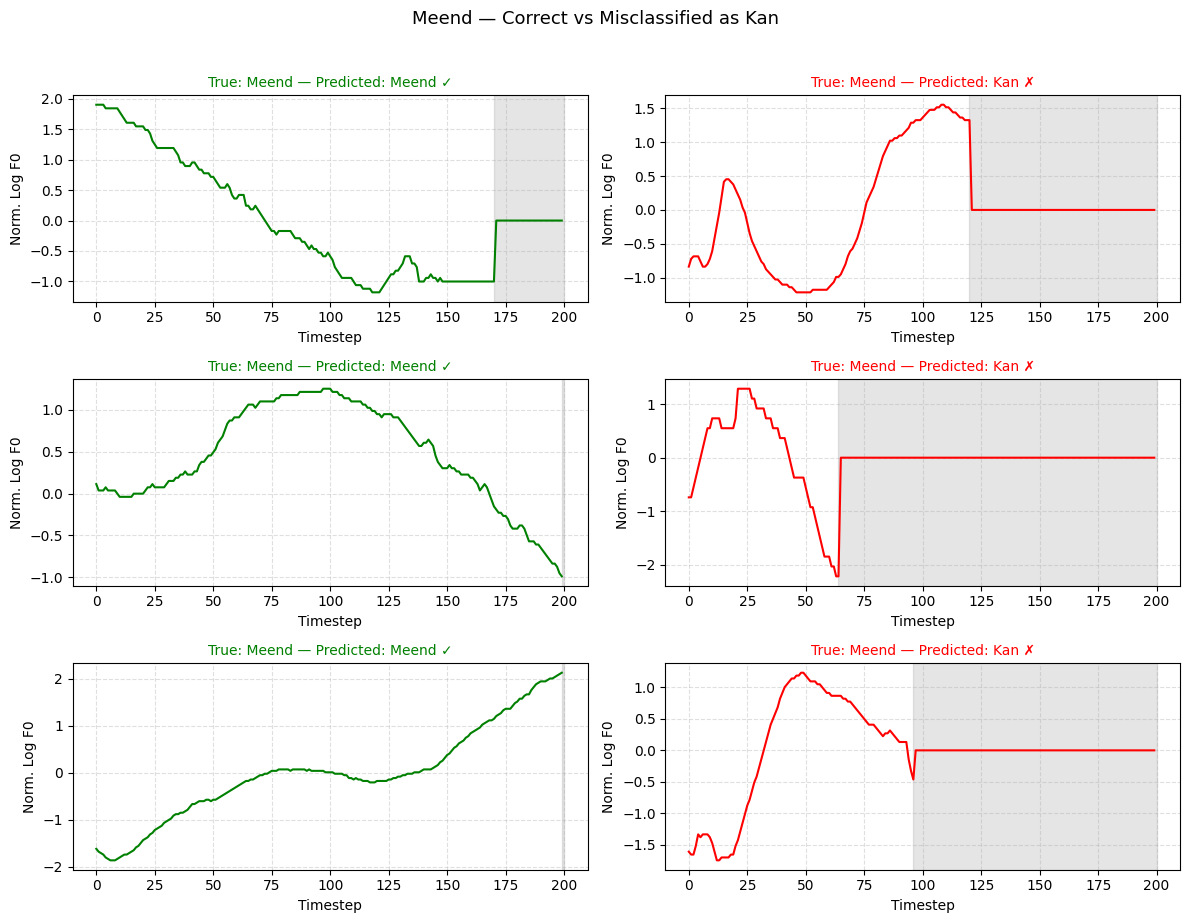

Correct Andolan: 1
Andolan misclassified as Murki: 2


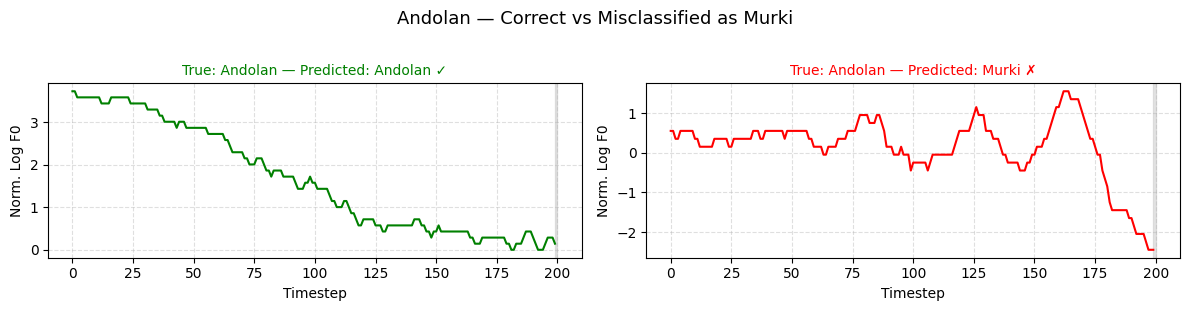

In [33]:
# Show all Meend predicted as Andolan
visualize_class_errors(model, test_loader, label_map, true_class="Meend", pred_class="Kan",max_plots=3)

# Or any other combination
visualize_class_errors(model, test_loader, label_map, true_class="Andolan", pred_class="Murki", max_plots=3)

#### With data augmentation

In [21]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, model=OrnamentTCN(input_size=1, num_classes=4), checkpoint_name="tcn_aug")


X shape: (4125, 1, 200)
y shape: (4125,)
Skipped: 0
Label distribution: {'Kan': 1426, 'Meend': 1290, 'Murki': 1299, 'Andolan': 110}
Train: 3300 | Test: 825
Epoch 01 | Loss: 1.2587 | Train Acc: 0.547 | Test Acc: 0.616
  -> New best Test Acc: 0.616
Epoch 02 | Loss: 1.1101 | Train Acc: 0.622 | Test Acc: 0.648
  -> New best Test Acc: 0.648
Epoch 03 | Loss: 1.0158 | Train Acc: 0.642 | Test Acc: 0.696
  -> New best Test Acc: 0.696
Epoch 04 | Loss: 1.0015 | Train Acc: 0.652 | Test Acc: 0.674
Epoch 05 | Loss: 0.9465 | Train Acc: 0.658 | Test Acc: 0.701
  -> New best Test Acc: 0.701
Epoch 06 | Loss: 0.9014 | Train Acc: 0.671 | Test Acc: 0.613
Epoch 07 | Loss: 0.8620 | Train Acc: 0.673 | Test Acc: 0.575
Epoch 08 | Loss: 0.8592 | Train Acc: 0.676 | Test Acc: 0.704
  -> New best Test Acc: 0.704
Epoch 09 | Loss: 0.8193 | Train Acc: 0.692 | Test Acc: 0.657
Epoch 10 | Loss: 0.8010 | Train Acc: 0.697 | Test Acc: 0.722
  -> New best Test Acc: 0.722
Epoch 11 | Loss: 0.7898 | Train Acc: 0.705 | Test Acc:

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.73      0.64      0.68       286
       Meend       0.81      0.76      0.79       258
       Murki       0.80      0.82      0.81       260
     Andolan       0.33      1.00      0.50        22

    accuracy                           0.74       826
   macro avg       0.67      0.80      0.69       826
weighted avg       0.77      0.74      0.75       826

=== Per-class Metrics ===
Kan        | Precision: 0.729 | Recall: 0.640 | F1: 0.682
Meend      | Precision: 0.811 | Recall: 0.764 | F1: 0.786
Murki      | Precision: 0.797 | Recall: 0.815 | F1: 0.806
Andolan    | Precision: 0.333 | Recall: 1.000 | F1: 0.500

Macro avg  | Precision: 0.668 | Recall: 0.805 | F1: 0.694


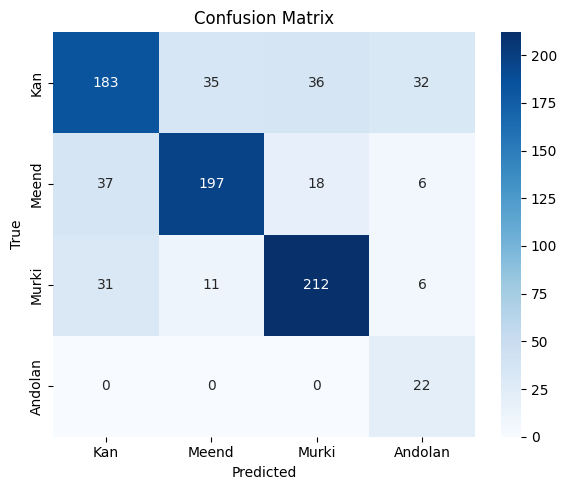

Precision: [0.72908367 0.81069959 0.79699248 0.33333333]
Recall:    [0.63986014 0.76356589 0.81538462 1.        ]
F1:        [0.68156425 0.78642715 0.80608365 0.5       ]


In [37]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

Correct Kan: 222
Kan misclassified as Meend: 30


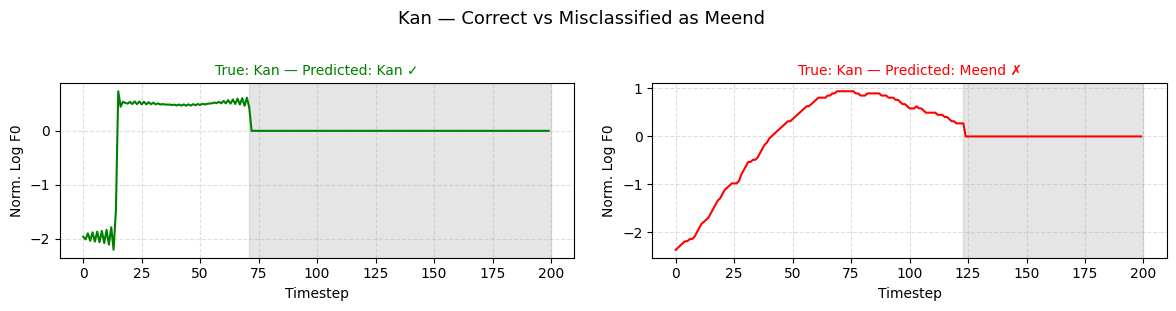

Correct Meend: 200
Meend misclassified as Kan: 43


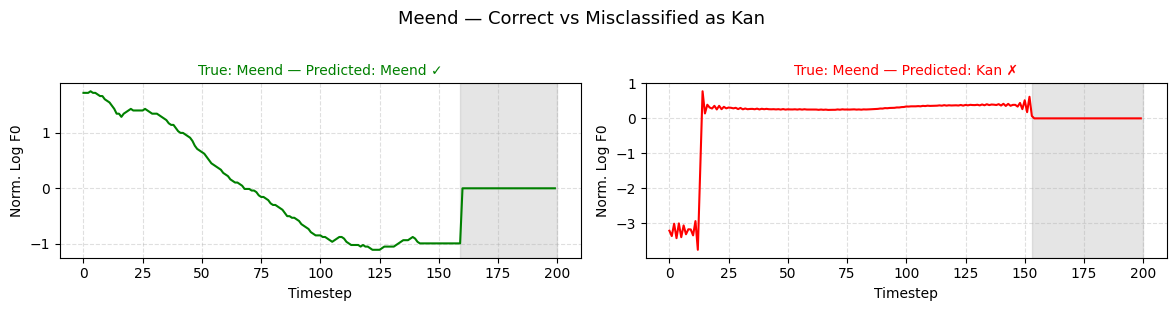

Correct Murki: 199
Murki misclassified as Kan: 46


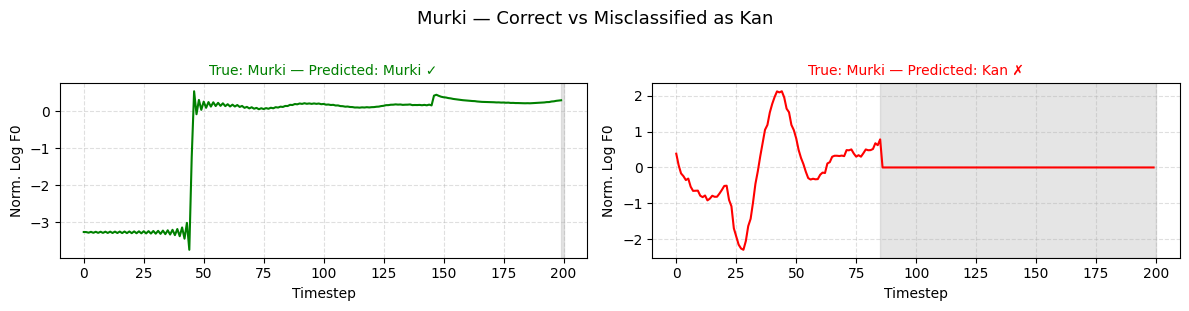

Correct Andolan: 19
Andolan misclassified as Kan: 1


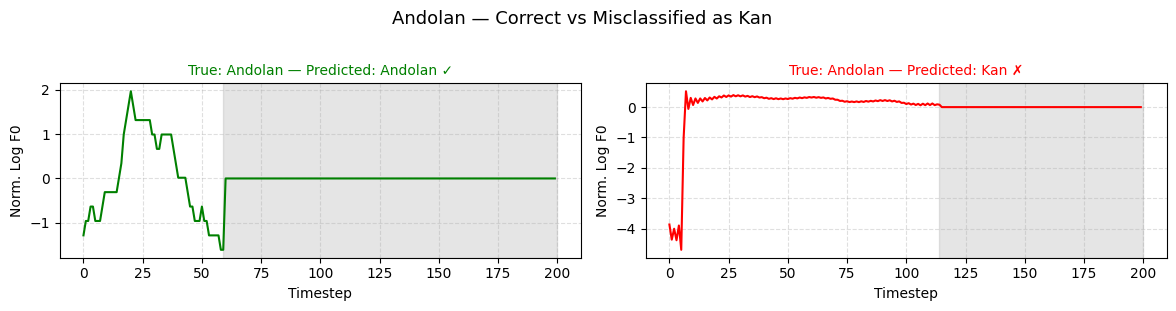

In [23]:
# Show all Meend predicted as Andolan
visualize_class_errors(model, test_loader, label_map, true_class="Kan", pred_class="Meend",max_plots=1)

# Or any other combination
visualize_class_errors(model, test_loader, label_map, true_class="Meend", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Murki", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Andolan", pred_class="Kan", max_plots=1)

#### Temporal Pyramid pooling (https://arxiv.org/pdf/1503.01224)

In [24]:
class TemporalPyramidPool(nn.Module):
    def __init__(self, levels=[1, 2, 4]):
        """
        levels: number of bins at each pyramid level
        e.g. [1, 2, 4] → pools to 1, 2, and 4 segments
        total output size = channels * sum(levels) = channels * 7
        """
        super().__init__()
        self.levels = levels
    
    def forward(self, x):
        # x: (batch, channels, time)
        pooled = []
        for level in self.levels:
            # AdaptiveAvgPool1d handles any input length
            pool = nn.AdaptiveAvgPool1d(level)(x)   # (batch, channels, level)
            pooled.append(pool.flatten(1))           # (batch, channels * level)
        return torch.cat(pooled, dim=1)              # (batch, channels * sum(levels))


class OrnamentTCN_TempPyr(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, 
                 kernel_size=3, pyramid_levels=[1, 2, 4]):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
            ResidualBlock(channels, kernel_size, dilation=16),
            ResidualBlock(channels, kernel_size, dilation=32),
        )
        self.tpp = TemporalPyramidPool(levels=pyramid_levels)
        
        # Output size = channels * sum(pyramid_levels)
        tpp_output_size = channels * sum(pyramid_levels)
        self.classifier = nn.Linear(tpp_output_size, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.tpp(out)          # (batch, channels * sum(levels))
        return self.classifier(out)

In [25]:
# After running extract_ornament_segments
#X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
#train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
#model = train_tcn(train_loader, test_loader, epochs=30, checkpoint_dir="checkpoints_temp")
model = train_tcn(train_loader, test_loader, model=OrnamentTCN_TempPyr(input_size=1, num_classes=4), checkpoint_name="TPP_aug")

Epoch 01 | Loss: 1.3143 | Train Acc: 0.513 | Test Acc: 0.451
  -> New best Test Acc: 0.451
Epoch 02 | Loss: 1.1720 | Train Acc: 0.575 | Test Acc: 0.657
  -> New best Test Acc: 0.657
Epoch 03 | Loss: 1.0385 | Train Acc: 0.629 | Test Acc: 0.567
Epoch 04 | Loss: 0.9823 | Train Acc: 0.642 | Test Acc: 0.690
  -> New best Test Acc: 0.690
Epoch 05 | Loss: 0.9282 | Train Acc: 0.660 | Test Acc: 0.592
Epoch 06 | Loss: 0.9000 | Train Acc: 0.667 | Test Acc: 0.623
Epoch 07 | Loss: 0.8382 | Train Acc: 0.681 | Test Acc: 0.639
Epoch 08 | Loss: 0.8523 | Train Acc: 0.677 | Test Acc: 0.708
  -> New best Test Acc: 0.708
Epoch 09 | Loss: 0.8168 | Train Acc: 0.688 | Test Acc: 0.709
  -> New best Test Acc: 0.709
Epoch 10 | Loss: 0.7928 | Train Acc: 0.695 | Test Acc: 0.701
Epoch 11 | Loss: 0.7617 | Train Acc: 0.699 | Test Acc: 0.703
Epoch 12 | Loss: 0.7470 | Train Acc: 0.710 | Test Acc: 0.725
  -> New best Test Acc: 0.725
Epoch 13 | Loss: 0.7185 | Train Acc: 0.718 | Test Acc: 0.698
Epoch 14 | Loss: 0.6941 | T

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.78      0.65      0.71       286
       Meend       0.73      0.86      0.79       258
       Murki       0.86      0.79      0.82       260
     Andolan       0.48      0.95      0.64        22

    accuracy                           0.77       826
   macro avg       0.71      0.81      0.74       826
weighted avg       0.78      0.77      0.77       826

=== Per-class Metrics ===
Kan        | Precision: 0.775 | Recall: 0.650 | F1: 0.707
Meend      | Precision: 0.734 | Recall: 0.864 | F1: 0.794
Murki      | Precision: 0.861 | Recall: 0.788 | F1: 0.823
Andolan    | Precision: 0.477 | Recall: 0.955 | F1: 0.636

Macro avg  | Precision: 0.712 | Recall: 0.814 | F1: 0.740


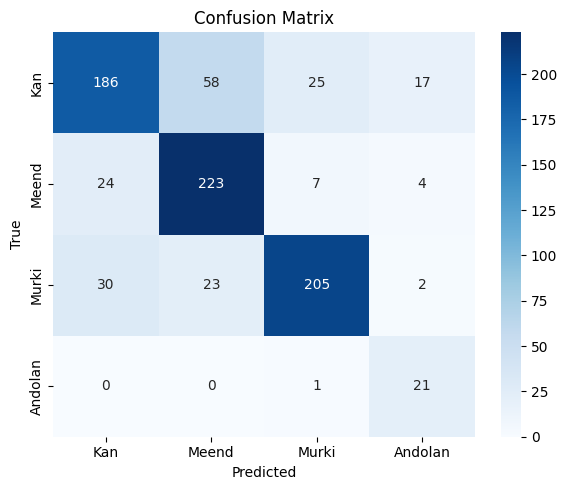

Precision: [0.775      0.73355263 0.86134454 0.47727273]
Recall:    [0.65034965 0.86434109 0.78846154 0.95454545]
F1:        [0.70722433 0.79359431 0.82329317 0.63636364]


In [41]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

Correct Kan: 185
Kan misclassified as Murki: 43


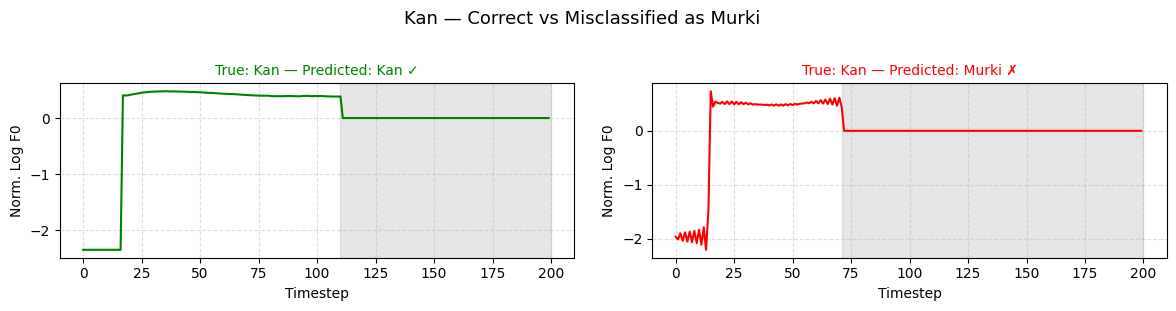

Correct Meend: 197
Meend misclassified as Kan: 32


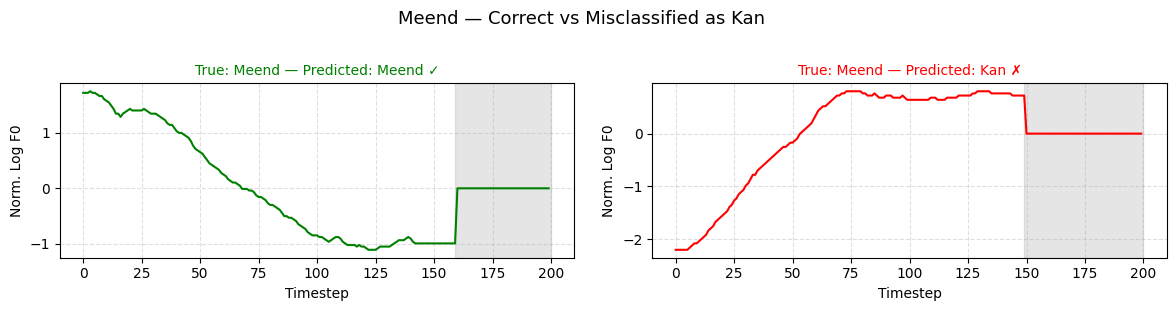

Correct Murki: 219
Murki misclassified as Kan: 27


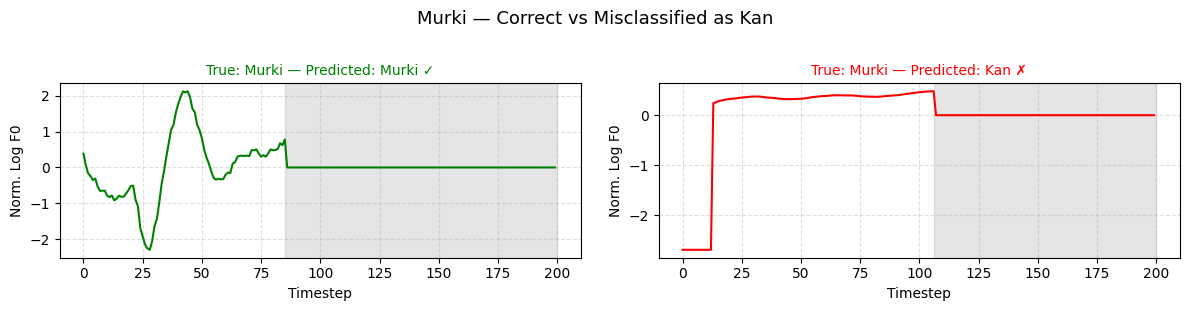

Correct Andolan: 19
Andolan misclassified as Kan: 1


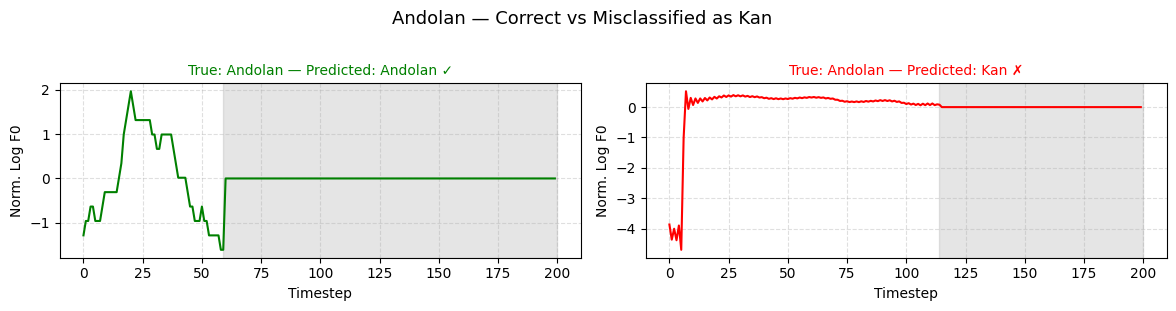

In [26]:
visualize_class_errors(model, test_loader, label_map, true_class="Kan", pred_class="Murki", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Meend", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Murki", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Andolan", pred_class="Kan", max_plots=1)

### Plot errors
As expected most of the misclassified errors where the very fast (small in time) ornamentations

Temporal pyramid pooling:

The problem with pooling to just 1 number (global average) is that you lose all shape information:
Meend (smooth glide):     [6.9, 7.1, 7.3, 7.5, 7.7, 7.9, 8.1, 8.3]
Murki (rapid oscillation):[6.9, 8.3, 6.9, 8.3, 6.9, 8.3, 6.9, 8.3]

Global average of Meend:  7.6
Global average of Murki:  7.6 

TPP solves this by pooling at multiple scales at once and combining them:
Same sequences, now with TPP (levels 1, 2, 4):

Level 1 (1 bin = global):
Meend:  [7.6]
Murki:  [7.6]  ← still same at this level

Level 2 (2 bins = two halves):
Meend:  [7.2,  8.0]   ← starts low, ends high (smooth glide)
Murki:  [7.6,  7.6]   ← both halves same (oscillating)

Level 4 (4 bins = four quarters):
Meend:  [7.0, 7.4, 7.8, 8.2]  ← steadily increasing
Murki:  [7.6, 7.6, 7.6, 7.6]  ← all quarters same

Final concatenated vector:
Meend:  [7.6,  7.2, 8.0,  7.0, 7.4, 7.8, 8.2]
Murki:  [7.6,  7.6, 7.6,  7.6, 7.6, 7.6, 7.6]
         ↑      ↑            ↑
       global  halves      quarters


However TPP doesn't always work in favor of the model: In cases where we have a small dataset (like ours) there's a posibility of overfitting

### Attention pooling 

In [27]:
class AttentionPool(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # learns a score for each timestep
        self.attention = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels, 1, kernel_size=1)  # score per timestep
        )
    
    def forward(self, x):
        # x: (batch, channels, time)
        
        # compute attention scores
        scores = self.attention(x)          # (batch, 1, time)
        weights = torch.softmax(scores, dim=2)  # (batch, 1, time) sums to 1
        
        # weighted sum over time
        out = (x * weights).sum(dim=2)      # (batch, channels)
        return out

In [28]:
class OrnamentTCN_Attention(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
            ResidualBlock(channels, kernel_size, dilation=16),
            ResidualBlock(channels, kernel_size, dilation=32),
        )
        self.pool = AttentionPool(channels)  # replaces AdaptiveAvgPool1d
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.pool(out)        # (batch, channels)
        return self.classifier(out)

In [29]:
#model = train_tcn_attention(train_loader, test_loader, epochs=30, checkpoint_dir="checkpoints_attention")
model = train_tcn(train_loader, test_loader, model=OrnamentTCN_Attention(input_size=1, num_classes=4), checkpoint_name="attention_aug")

Epoch 01 | Loss: 1.2227 | Train Acc: 0.568 | Test Acc: 0.441
  -> New best Test Acc: 0.441
Epoch 02 | Loss: 1.0686 | Train Acc: 0.623 | Test Acc: 0.681
  -> New best Test Acc: 0.681
Epoch 03 | Loss: 1.0157 | Train Acc: 0.643 | Test Acc: 0.648
Epoch 04 | Loss: 0.9485 | Train Acc: 0.660 | Test Acc: 0.668
Epoch 05 | Loss: 0.9085 | Train Acc: 0.658 | Test Acc: 0.685
  -> New best Test Acc: 0.685
Epoch 06 | Loss: 0.8667 | Train Acc: 0.682 | Test Acc: 0.687
  -> New best Test Acc: 0.687
Epoch 07 | Loss: 0.8426 | Train Acc: 0.678 | Test Acc: 0.691
  -> New best Test Acc: 0.691
Epoch 08 | Loss: 0.8037 | Train Acc: 0.678 | Test Acc: 0.688
Epoch 09 | Loss: 0.7773 | Train Acc: 0.699 | Test Acc: 0.672
Epoch 10 | Loss: 0.7317 | Train Acc: 0.717 | Test Acc: 0.678
Epoch 11 | Loss: 0.7009 | Train Acc: 0.717 | Test Acc: 0.606
Epoch 12 | Loss: 0.6897 | Train Acc: 0.723 | Test Acc: 0.697
  -> New best Test Acc: 0.697
Epoch 13 | Loss: 0.6429 | Train Acc: 0.734 | Test Acc: 0.687
Epoch 14 | Loss: 0.6542 | T

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.68      0.76      0.71       286
       Meend       0.84      0.65      0.73       258
       Murki       0.84      0.78      0.81       260
     Andolan       0.28      0.82      0.42        22

    accuracy                           0.73       826
   macro avg       0.66      0.75      0.67       826
weighted avg       0.77      0.73      0.74       826

=== Per-class Metrics ===
Kan        | Precision: 0.675 | Recall: 0.755 | F1: 0.713
Meend      | Precision: 0.839 | Recall: 0.647 | F1: 0.731
Murki      | Precision: 0.835 | Recall: 0.781 | F1: 0.807
Andolan    | Precision: 0.281 | Recall: 0.818 | F1: 0.419

Macro avg  | Precision: 0.658 | Recall: 0.750 | F1: 0.667


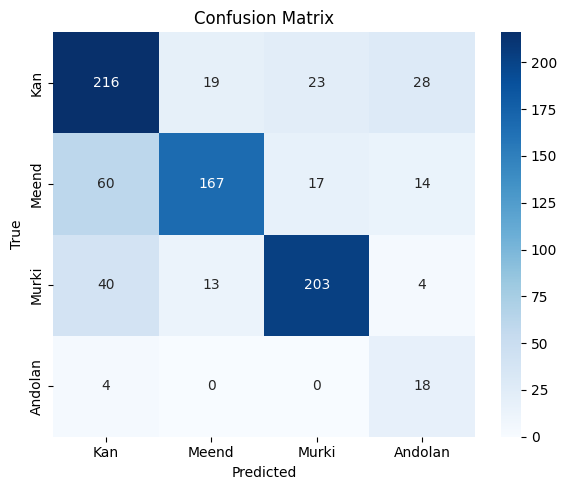

Precision: [0.675      0.83919598 0.83539095 0.28125   ]
Recall:    [0.75524476 0.64728682 0.78076923 0.81818182]
F1:        [0.71287129 0.73085339 0.80715706 0.41860465]


In [46]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

Correct Kan: 228
Kan misclassified as Murki: 20


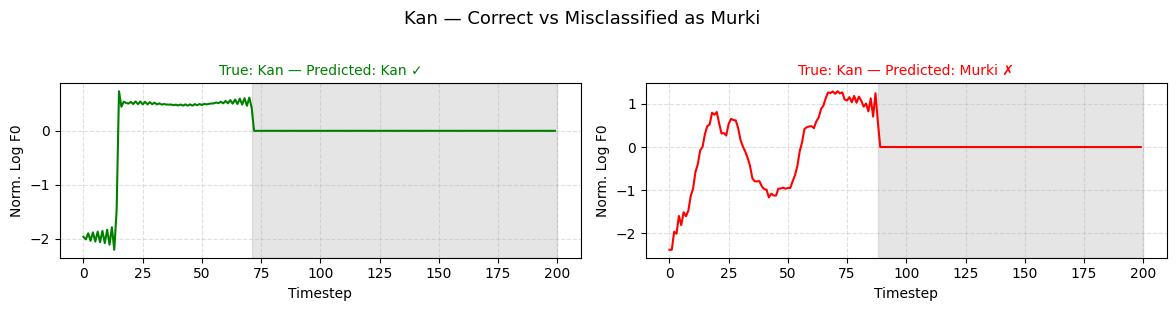

Correct Meend: 179
Meend misclassified as Kan: 58


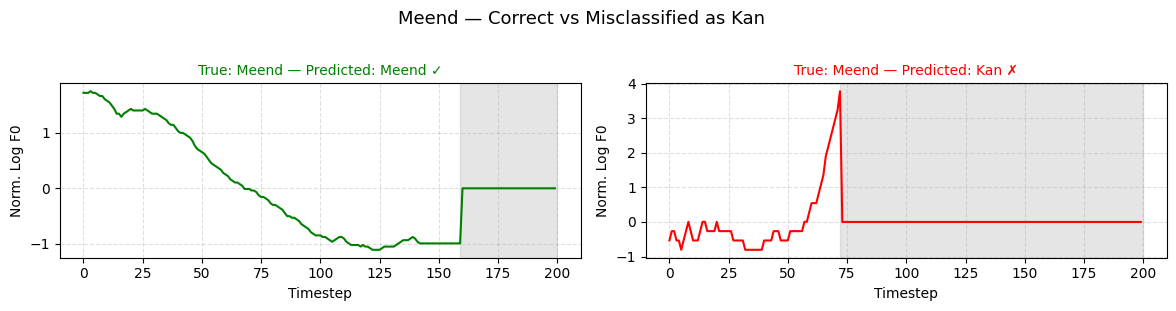

Correct Murki: 200
Murki misclassified as Kan: 37


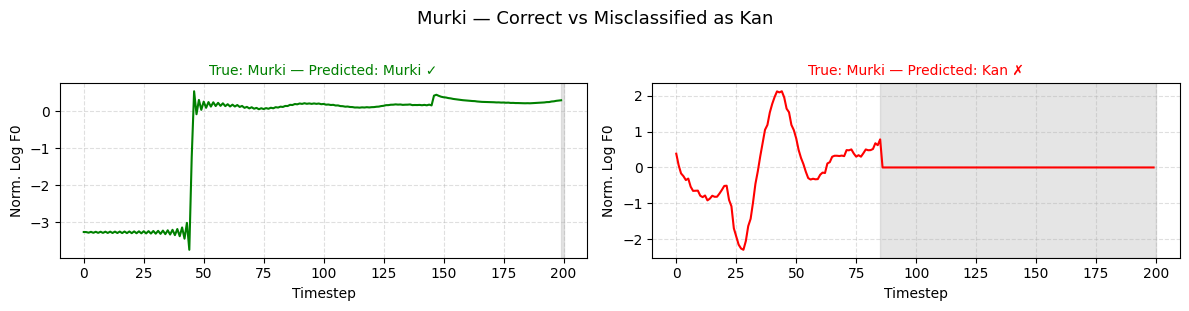

Correct Andolan: 18
Andolan misclassified as Kan: 2


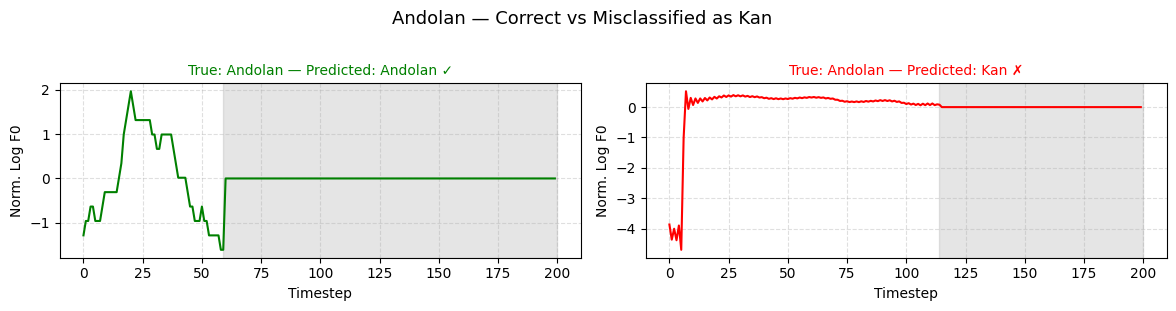

In [30]:
visualize_class_errors(model, test_loader, label_map, true_class="Kan", pred_class="Murki", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Meend", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Murki", pred_class="Kan", max_plots=1)

visualize_class_errors(model, test_loader, label_map, true_class="Andolan", pred_class="Kan", max_plots=1)